# Canadian Global Ensemble Prediction System (GEPS)

In this example, we will complete the following:

1) Download the first 24 hours of GEPS Data for 850mb Temperature
2) Find the ensemble mean between all ensemble members
3) We will create a set of graphics of ensemble mean 850mb Temperature for the next 24 hours.

[***WxData GEPS Client Documentation***](https://edrewitz.github.io/WxData/geps)

## Imports

In [1]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import pandas as pd

from wxdata import geps
from datetime import timedelta

# IPython magic command used in Jupyter Notebooks to display plots directly below the code cell that generates them
%matplotlib inline

### WxData GEPS Client

```python
def geps(final_forecast_hour=384, 
             western_bound=-180, 
             eastern_bound=180, 
             northern_bound=90, 
             southern_bound=-90, 
             step=1,
             path=f"GEPS",
             proxies=None, 
             clear_recycle_bin=False,
             process_data=True,
             convert_temperature=True,
             convert_to='celsius',
             chunk_size=8192,
             notifications='off',
             level_type='pressure',
             clear_data=False,
             variable='geopotential height',
             level=500,
             cat='members'):
```

In this example, we will need to change the following:

1) Change level to 850mb
2) Change variable to temperature
3) Change our bounds to reflect CONUS, Southern Canada & Northern Mexico 

We will also change our `final_forecast_hour=24` from the default `final_forecast_hour=384` as we only want to download the first 24 hours worth of data.

In [2]:
ds = geps(final_forecast_hour=24,
              western_bound=-130,
              eastern_bound=-65,
              northern_bound=60,
              southern_bound=20,
              level=850,
              variable='temperature')

Scanning https://dd.weather.gc.ca/ GEPS TEMPERATURE 850mb
Please Wait...
Server Scan Complete!


CMC_geps-raw_TMP_ISBL_0850_latlon0p5x0p5_2026091012_P000_allmbrs.grib2:   0%|          | 0.00/3.59M [00:00<?, …

CMC_geps-raw_TMP_ISBL_0850_latlon0p5x0p5_2026091012_P003_allmbrs.grib2:   0%|          | 0.00/3.60M [00:00<?, …

CMC_geps-raw_TMP_ISBL_0850_latlon0p5x0p5_2026091012_P006_allmbrs.grib2:   0%|          | 0.00/3.61M [00:00<?, …

CMC_geps-raw_TMP_ISBL_0850_latlon0p5x0p5_2026091012_P009_allmbrs.grib2:   0%|          | 0.00/3.60M [00:00<?, …

...

CMC_geps-raw_TMP_ISBL_0850_latlon0p5x0p5_2026091012_P015_allmbrs.grib2:   0%|          | 0.00/3.61M [00:00<?, …

CMC_geps-raw_TMP_ISBL_0850_latlon0p5x0p5_2026091012_P018_allmbrs.grib2:   0%|          | 0.00/3.62M [00:00<?, …

CMC_geps-raw_TMP_ISBL_0850_latlon0p5x0p5_2026091012_P021_allmbrs.grib2:   0%|          | 0.00/3.63M [00:00<?, …

CMC_geps-raw_TMP_ISBL_0850_latlon0p5x0p5_2026091012_P024_allmbrs.grib2:   0%|          | 0.00/3.64M [00:00<?, …

GEPS TEMPERATURE 850mb Download Complete!

Data Processing...
GEPS Data Processing Complete: TEMPERATURE - 850mb


## Inspecting Our Data

In [3]:
ds

<xarray.Dataset> Size: 8MB
Dimensions:        (number: 20, step: 9, latitude: 81, longitude: 131)
Coordinates:
  * number         (number) int64 160B 1 2 3 4 5 6 7 8 ... 14 15 16 17 18 19 20
  * step           (step) float64 72B 0.0 3.0 6.0 9.0 12.0 15.0 18.0 21.0 24.0
  * latitude       (latitude) float64 648B 20.0 20.5 21.0 ... 59.0 59.5 60.0
  * longitude      (longitude) float64 1kB -130.0 -129.5 -129.0 ... -65.5 -65.0
    time           datetime64[ns] 8B ...
    isobaricInhPa  float64 8B ...
    valid_time     datetime64[ns] 8B ...
Data variables:
    temperature    (step, number, latitude, longitude) float32 8MB dask.array<chunksize=(1, 20, 81, 131), meta=np.ndarray>
Attributes:
    GRIB_edition:            2
    GRIB_centre:             cwao
    GRIB_centreDescription:  Canadian Meteorological Service - Montreal
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             Canadian Meteorological Service - Montreal
    history:                 2026-09-10T15:27 GRIB to CDM+CF via cfgrib-0.9.1...

## Finding The Ensemble Mean

In [4]:
ds = ds.mean(dim='number')

In [5]:
ds

<xarray.Dataset> Size: 384kB
Dimensions:        (step: 9, latitude: 81, longitude: 131)
Coordinates:
  * step           (step) float64 72B 0.0 3.0 6.0 9.0 12.0 15.0 18.0 21.0 24.0
  * latitude       (latitude) float64 648B 20.0 20.5 21.0 ... 59.0 59.5 60.0
  * longitude      (longitude) float64 1kB -130.0 -129.5 -129.0 ... -65.5 -65.0
    time           datetime64[ns] 8B ...
    isobaricInhPa  float64 8B ...
    valid_time     datetime64[ns] 8B ...
Data variables:
    temperature    (step, latitude, longitude) float32 382kB dask.array<chunksize=(1, 81, 131), meta=np.ndarray>
Attributes:
    GRIB_edition:            2
    GRIB_centre:             cwao
    GRIB_centreDescription:  Canadian Meteorological Service - Montreal
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             Canadian Meteorological Service - Montreal
    history:                 2026-09-10T15:27 GRIB to CDM+CF via cfgrib-0.9.1...

## Creating Our Plot

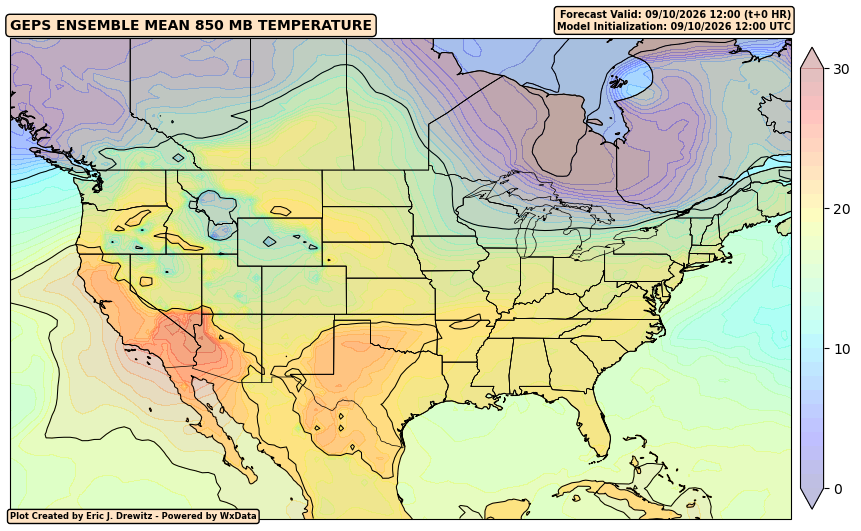

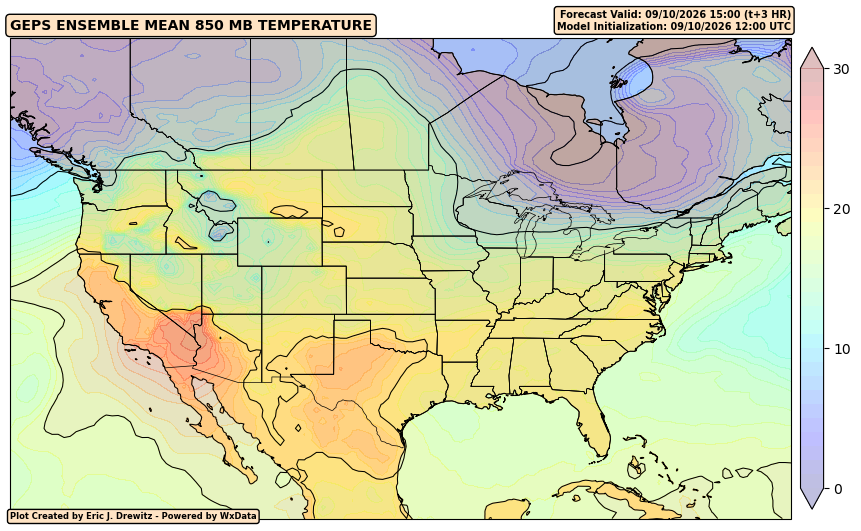

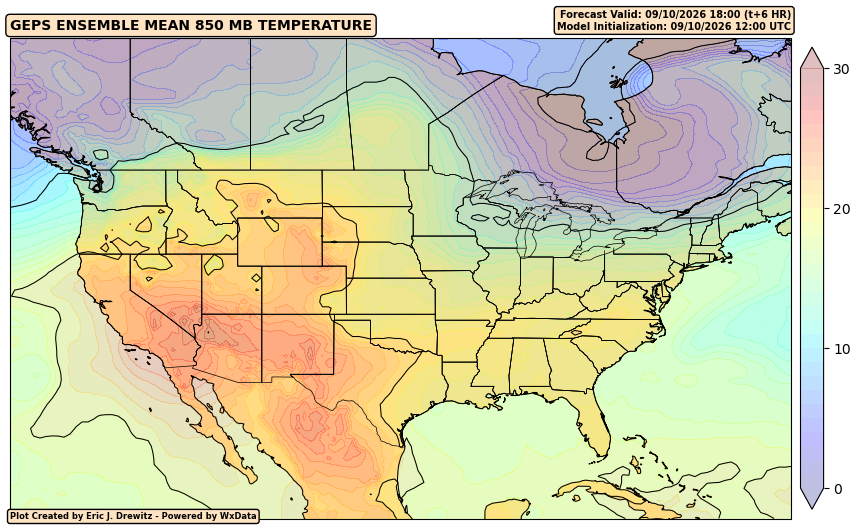

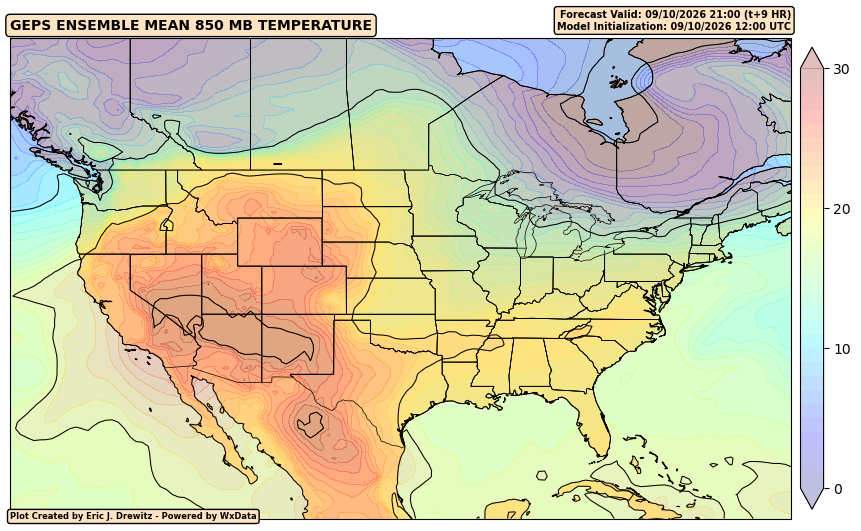

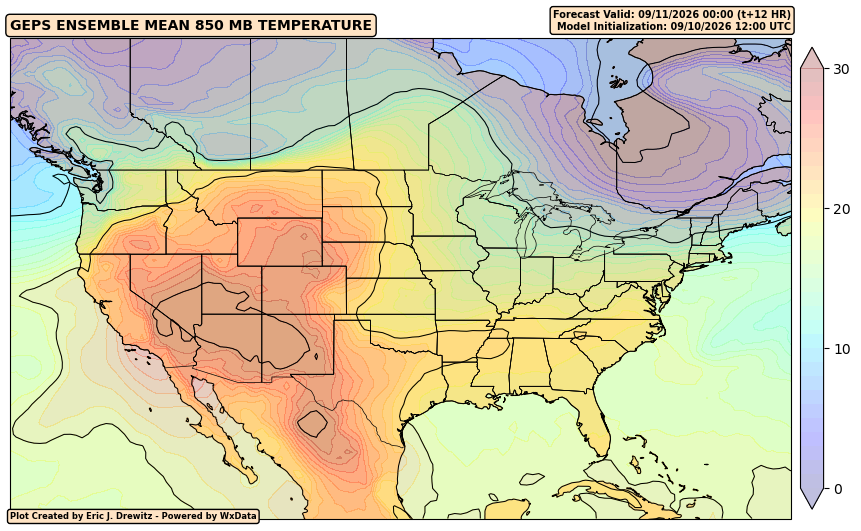

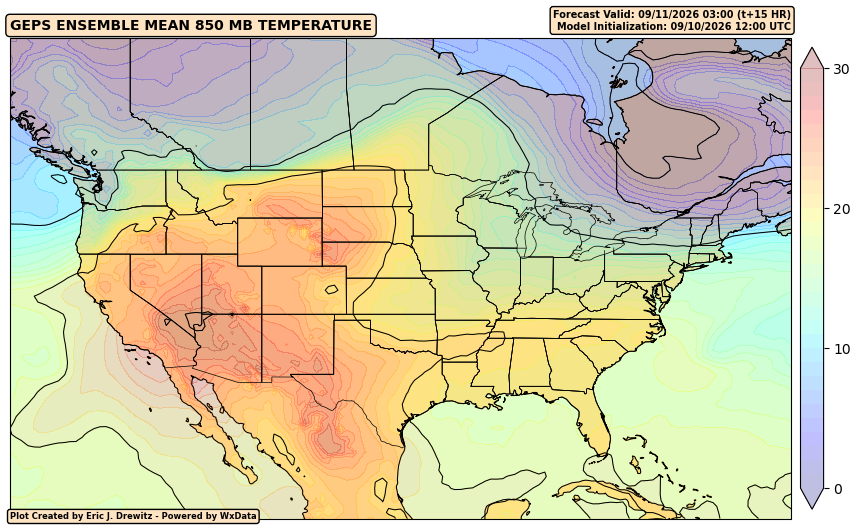

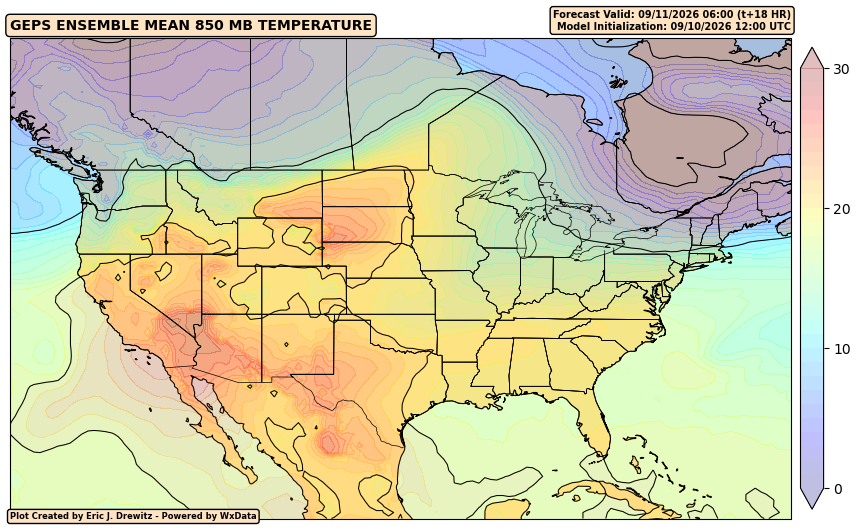

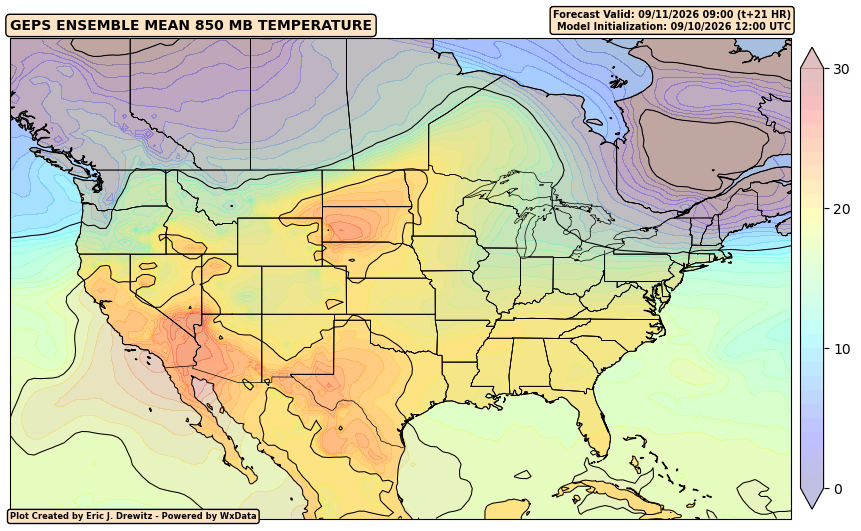

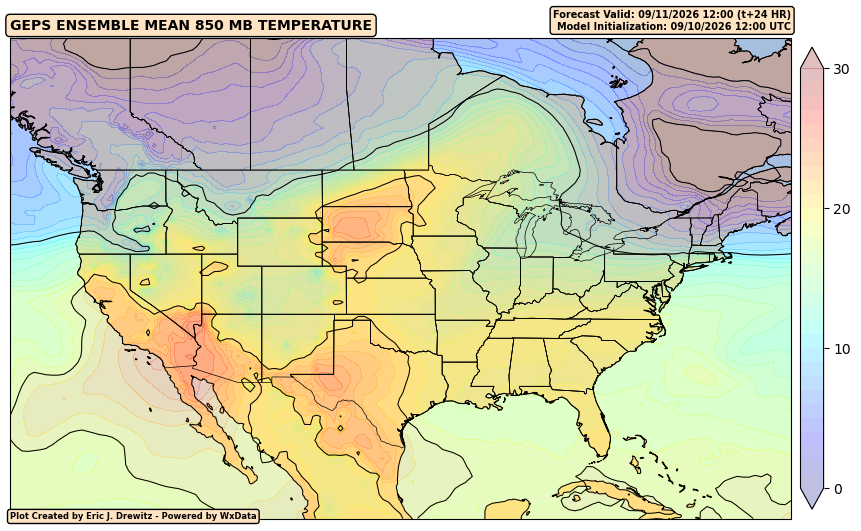

In [6]:
# Create our figure
for i in range(0, len(ds['step']), 1):
    fig = plt.figure(figsize=(12,12))
    
    # Create our subplot with a PlateCarree (lat/lon) projection
    ax = fig.add_subplot(1,1,1, projection=ccrs.PlateCarree())
    
    # Set our boundaries in a latlon format of [western_bound, eastern_bound, southern_bound, northern_bound] followed by our PlateCarree projection
    ax.set_extent([-130, -65, 20, 60], ccrs.PlateCarree())
    
    # Add our features to the map 
    # Add our coastlines
    ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.75, zorder=3)
    
    # Add the oceans, land, states, lakes and Canadian provinces and color them light cyan
    ax.add_feature(cfeature.OCEAN, color='lightcyan', zorder=1)
    ax.add_feature(cfeature.LAKES, color='lightcyan', zorder=1)
    ax.add_feature(cfeature.LAND, color='navajowhite', zorder=1)
    ax.add_feature(cfeature.STATES, edgecolor='black', linewidth=0.5, zorder=5)
    province_boundaries = cfeature.NaturalEarthFeature(
        category="cultural",
        name="admin_1_states_provinces_lines",
        scale="50m",
        facecolor="none",
        edgecolor="black",
    )
    ax.add_feature(province_boundaries, linewidth=0.5, zorder=5)
    
    # Add our 850mb temperature contours
    c = ax.contour(ds['longitude'], 
                   ds['latitude'], 
                   ds['temperature'][i, :, :], 
                   levels=np.arange(0, 40, 10), 
                   transform=ccrs.PlateCarree(), 
                   colors='black', 
                   linewidths=0.75)
    
    # Add our filled contours for 850mb temperature
    cs = ax.contourf(ds['longitude'], 
                   ds['latitude'], 
                   ds['temperature'][i, :, :], 
                   levels=np.arange(0, 31, 1), 
                   transform=ccrs.PlateCarree(),
                   alpha=0.25,
                   cmap='jet',
                   extend='both')
    
    # Create our colorbar for our filled contours
    fig.colorbar(cs, 
                 shrink=0.5, 
                 pad=0.01,
                 ticks=np.arange(0, 40, 10))
    

    # Plot title
    plt.title(f"GEPS ENSEMBLE MEAN 850 MB TEMPERATURE", 
                   fontsize=10, 
                   fontweight='bold',
                   bbox=dict(boxstyle='round', 
                                facecolor='bisque'),
                   loc='left')
    
    # Extract our valid time as a datetime object
    valid_time = pd.to_datetime(ds['valid_time'].values)
    
    # Gets our new forecast hour (eventhough we are plotting the initial frame)
    times = ds['step'].values
    forecast_time = valid_time + timedelta(hours=int(times[i]))
    
    # Secondary title for our model runtime
    plt.title(f"Forecast Valid: {forecast_time.strftime('%m/%d/%Y %H:00')} (t+{int(times[i])} HR)\nModel Initialization: {valid_time.strftime('%m/%d/%Y %H:00')} UTC", 
                    fontsize=7, 
                    fontweight='bold',
                    bbox=dict(boxstyle='round', 
                                facecolor='bisque'),
                    loc='right')
    
    # Adding my signature on the plot
    ax.text(0, 
            -0.001, 
            f"Plot Created by Eric J. Drewitz - Powered by WxData", 
            transform=ax.transAxes, 
            fontsize=6, 
            fontweight='bold', 
            bbox=dict(boxstyle='round', 
                    facecolor='bisque'))

    plt.show()